SISTECH 2026 — MLOps Hands-On 2
## Membangun Mesin Prediksi & Continual Learning untuk Risk Score

Selamat datang di **Hands-On 2**! 🎉 Kalau di Hands-On 1 fokusnya adalah menyiapkan
data (EDA, feature engineering, pseudo-labeling Risk Score), di sini fokusnya adalah
**membangun mesin prediksi**: model yang belajar memetakan fitur ruang–waktu menjadi
Risk Score, sekaligus mampu **diperbarui seiring datangnya data baru**.

**Alur yang akan kita lalui:**
1. Load dataset fitur + label dari Hands-On 1
2. **Baseline non-ML** — patokan minimal sebelum melatih model apa pun
3. **Feature Vector Assembly** — merakit fitur jadi input yang konsisten
4. **Model regresi** — melatih model untuk memprediksi Risk Score
5. **Evaluasi model** — dibandingkan eksplisit dengan baseline
6. **Simulasi continual learning** — data datang bertahap dalam beberapa batch
7. **Drift detection** — mendeteksi kapan data baru "berbeda" secara signifikan
8. **Checkpoint retraining & model versioning** — retrain bersyarat + rekam jejak model

> 🧭 **Prinsip inti:** model yang bagus di hari pertama bisa outdated di hari ke-100.
> MLOps bukan cuma soal melatih model sekali, tapi soal membangun **siklus** yang membuat
> model tetap relevan — dan **jujur mencatat** kapan siklus itu berhasil atau gagal.

---

> ## ⚠️ Cara memakai notebook ini — BACA DULU
>
> Sama seperti Tutorial 1, notebook ini **sengaja dibuat sebagai versi paling sederhana**.
> Ia berjalan dari atas sampai bawah dan menghasilkan model + rekam jejak versi, **tapi
> banyak keputusannya sengaja dibuat seadanya** supaya kalian bisa melihat *mekanismenya
> bekerja* — bukan supaya kalian menyalinnya bulat-bulat.
>
> Sepanjang notebook kalian akan menemukan dua jenis blok:
> - 🔧 **Versi Sederhana (Baseline)** — kode yang berfungsi tapi jelas belum optimal.
> - 🙋 **Giliran Kalian** — di sinilah kalian mengambil alih: mengembangkan, mengganti,
>   atau memperbaiki versi sederhana tadi, lalu **menjustifikasinya di laporan**.
>
> Bagian yang paling besar bobot penilaiannya (**continual learning**, 35%) justru yang
> paling "mentah" di sini. **Nilai kalian datang dari seberapa jauh kalian mengembangkannya,
> bukan dari menjalankan notebook ini apa adanya.**

# 0. Installation & Setup

Kita memakai stack standar data science + ML: `pandas`, `numpy`, `matplotlib`, `seaborn`,
`scikit-learn`, `scipy`, dan `joblib` (untuk menyimpan model/checkpoint).

In [1]:
import os
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Load Dataset Fitur + Label dari Hands-On 1

Kita melanjutkan **langsung** dari `features_labels.csv` yang dihasilkan di akhir
Hands-On 1: dataset dengan satu baris per unit analisis (sel grid × hari × jam),
berisi fitur ruang–waktu dan label `risk_score` (0–100).

**README**: Langkah pertama adalah mengunduh `features_labels.csv` dari Files notebook Hands-On 1 lalu upload ke project session ini. Upload dapat ditemukan di Files.

Icon Files:

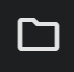

Icon Upload:

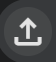

In [2]:
DATA_PATH = "features_labels.csv"  # ganti path ini kalau file kalian ada di lokasi lain

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset dari Hands-On 1 berhasil dimuat: {df.shape}")
else:
    # -----------------------------------------------------------------------
    # ⚠️ FALLBACK: dataset sintetis KECIL agar notebook ini tetap bisa dijalankan
    # end-to-end walau kalian belum mengunggah file dari Hands-On 1.
    # JANGAN pakai data sintetis ini untuk mengerjakan tugas — ganti DATA_PATH
    # di atas dengan file `features_labels.csv` (atau .parquet) hasil HO1 kalian.
    # -----------------------------------------------------------------------
    print(f"'{DATA_PATH}' tidak ditemukan. Membuat dataset SINTETIS untuk demo notebook...")
    rng = np.random.default_rng(0)
    n_cells = 150
    lat_r = rng.uniform(41.65, 42.00, n_cells).round(2)
    lon_r = rng.uniform(-87.90, -87.55, n_cells).round(2)
    cell_ids = [f"{la}_{lo}" for la, lo in zip(lat_r, lon_r)]

    rows = []
    for cid, la, lo in zip(cell_ids, lat_r, lon_r):
        for dow in range(7):
            for hour in range(0, 24, 3):  # subset jam biar ringkas
                crime_count = rng.poisson(3) + 1
                base = 10 + 40 * (np.sin(np.deg2rad(hour * 15)) + 1) / 2
                base += 15 * (1 if dow >= 5 else 0)
                base += crime_count * 1.5
                risk_score = float(np.clip(base + rng.normal(0, 5), 0, 100))
                rows.append({
                    "cell_id": cid, "lat_r": la, "lon_r": lo,
                    "dow": dow, "hour": hour,
                    "hour_sin": np.sin(2*np.pi*hour/24), "hour_cos": np.cos(2*np.pi*hour/24),
                    "dow_sin": np.sin(2*np.pi*dow/7), "dow_cos": np.cos(2*np.pi*dow/7),
                    "crime_count": crime_count, "risk_score": risk_score,
                })
    df = pd.DataFrame(rows)
    print(f"Dataset sintetis dibuat: {df.shape}")

df.head()

Dataset dari Hands-On 1 berhasil dimuat: (457696, 14)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,crime_count,arrest_rate,violent_share,risk_score
0,41.649_-87.54,41.649,-87.540,0,0,0.0,1.0,0.0,1.0,0,2,0.0,0.0,66.290971
1,41.649_-87.546,41.649,-87.546,0,0,0.0,1.0,0.0,1.0,0,1,0.0,0.0,66.374471
2,41.651_-87.527,41.651,-87.527,0,0,0.0,1.0,0.0,1.0,0,1,0.0,0.0,65.433914
3,41.651_-87.545,41.651,-87.545,0,0,0.0,1.0,0.0,1.0,0,1,0.0,1.0,65.937822
4,41.652_-87.61,41.652,-87.610,0,0,0.0,1.0,0.0,1.0,0,1,0.0,0.0,58.659261


In [3]:
df.describe().round(2)

,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,crime_count,arrest_rate,violent_share,risk_score
count,457696.00,457696.00,457696.0,457696.00,457696.00,457696.00,457696.00,457696.00,457696.00,457696.00,457696.00,457696.00,457696.00
mean,41.84,-87.67,3.0,12.42,-0.15,-0.04,-0.01,-0.01,0.28,1.20,0.14,0.31,53.67
std,0.09,0.06,2.0,6.88,0.67,0.73,0.70,0.71,0.45,0.71,0.33,0.45,4.94
min,41.64,-87.94,0.0,0.00,-1.00,-1.00,-0.97,-0.90,0.00,1.00,0.00,0.00,0.00
25%,41.77,-87.71,1.0,7.00,-0.87,-0.71,-0.78,-0.90,0.00,1.00,0.00,0.00,50.85
50%,41.86,-87.66,3.0,13.00,-0.26,-0.00,0.00,-0.22,0.00,1.00,0.00,0.00,53.96
75%,41.91,-87.63,5.0,18.00,0.50,0.71,0.78,0.62,1.00,1.00,0.00,1.00,56.87
max,42.02,-87.52,6.0,23.00,1.00,1.00,0.97,1.00,1.00,39.00,1.00,1.00,100.00


### Distribusi Risk Score

Sekilas cek ulang bentuk distribusi label sebelum melatih model apa pun — ini bekal
untuk memilih metrik evaluasi dan menafsirkan hasil nanti.

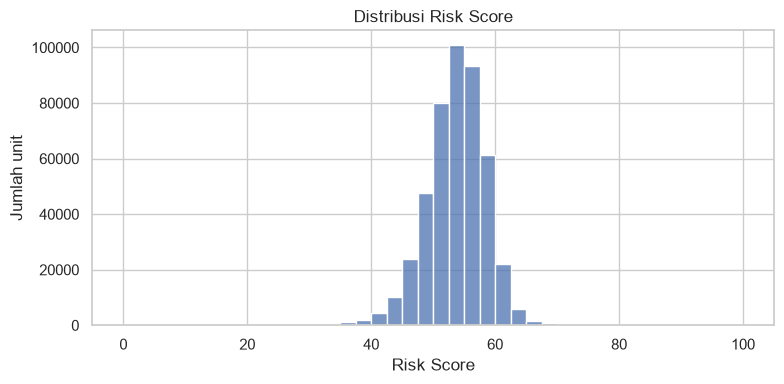

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["risk_score"], bins=40, color="#4C72B0")
plt.title("Distribusi Risk Score")
plt.xlabel("Risk Score"); plt.ylabel("Jumlah unit")
plt.tight_layout(); plt.show()

# 2. Baseline Non-ML — Historical Average

Sebelum melatih model ML apa pun, kita butuh **baseline**: prediktor sederhana yang
menjadi patokan minimal. Baseline menjawab pertanyaan kritis secara empiris: *apakah
model yang lebih kompleks benar-benar memberi nilai tambah dibanding pendekatan yang
jauh lebih sederhana?*

Pertanyaannya: apa prediksi paling logis untuk Risk Score suatu lokasi & waktu, kalau
kita **hanya** berbekal pola historis, tanpa melatih model ML sama sekali?

> 🔧 **Versi Sederhana (Baseline).** Kita coba tiga versi paling lugas:
> - **Global mean** — rata-rata Risk Score dari seluruh data training (mengabaikan
>   lokasi & waktu sama sekali).
> - **Rata-rata per sel** — pola spasial: "lokasi ini secara historis seberapa rawan?"
> - **Rata-rata per (hari, jam)** — pola temporal: "jam & hari ini secara historis
>   seberapa rawan, di mana pun lokasinya?"

In [5]:
TARGET_COL = "risk_score"

# Split evaluasi: 80% train, 20% test (acak, untuk evaluasi model & baseline statis)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")

train_df: (366156, 14)  |  test_df: (91540, 14)


In [6]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# --- Baseline 1: global mean ---
global_mean = train_df[TARGET_COL].mean()
pred_global = np.full(len(test_df), global_mean)
results.append(evaluate(test_df[TARGET_COL], pred_global, "Baseline: Global Mean"))

# --- Baseline 2: rata-rata per sel (pola spasial) ---
cell_mean_map = train_df.groupby("cell_id")[TARGET_COL].mean()
pred_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean).values
results.append(evaluate(test_df[TARGET_COL], pred_cell, "Baseline: Rata-rata per Sel"))

# --- Baseline 3: rata-rata per (hari, jam) (pola temporal) ---
hourdow_mean_map = train_df.groupby(["dow", "hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["dow", "hour"]])
pred_hourdow = hourdow_mean_map.reindex(idx).values
pred_hourdow = np.where(np.isnan(pred_hourdow), global_mean, pred_hourdow)
results.append(evaluate(test_df[TARGET_COL], pred_hourdow, "Baseline: Rata-rata per Jam+Hari"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.742,4.958,-0.000
1,Baseline: Rata-rata per Sel,3.275,4.471,0.187
2,Baseline: Rata-rata per Jam+Hari,3.468,4.635,0.126


### 🙋 Giliran Kalian — Baseline

Ini bagian yang **dinilai** sebagai bagian dari Baseline & Feature Vector Assembly (15%):
- Baseline mana yang paling kuat di data kalian? Menurut kalian **kenapa**?
- Coba **kombinasikan** dua pola sekaligus, misalnya rata-rata per (sel, jam) atau
  (sel, hari) — apakah lebih baik daripada memakai satu pola saja?
- Bagaimana strategi *fallback* kalau kombinasi (sel, jam, hari) tertentu tidak pernah
  muncul di data training (seperti yang kita tangani dengan `global_mean` di atas)?
- **Justifikasi** baseline pilihan kalian di laporan — baseline yang "masuk akal" jauh
  lebih penting daripada baseline yang "paling kompleks".

In [7]:
# Kombinasi pola: (cell_id, hour) dan (cell_id, dow), dengan fallback berjenjang.
# Fallback: kombinasi -> rata-rata per cell_id -> rata-rata per (dow, hour) -> global mean

def _map_with_fallback(test_series_df, group_cols, train_df, target_col, fallback_series):
    """Prediksi via rata-rata grup train_df[group_cols], fallback ke fallback_series bila NaN."""
    group_mean = train_df.groupby(group_cols)[target_col].mean()
    if len(group_cols) == 1:
        idx = test_series_df[group_cols[0]]
        pred = idx.map(group_mean)
    else:
        idx = pd.MultiIndex.from_frame(test_series_df[group_cols])
        pred = pd.Series(group_mean.reindex(idx).values, index=test_series_df.index)
    return pred.fillna(fallback_series).values

# --- Baseline 4: kombinasi (cell_id, hour) ---
pred_cell_hour = _map_with_fallback(
    test_df, ["cell_id", "hour"], train_df, TARGET_COL, pd.Series(global_mean, index=test_df.index)
)
results.append(evaluate(test_df[TARGET_COL], pred_cell_hour, "Baseline: Rata-rata per (Sel, Jam)"))

# --- Baseline 5: kombinasi (cell_id, dow), fallback ke rata-rata per sel dulu, baru global ---
fallback_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean)
pred_cell_dow = _map_with_fallback(
    test_df, ["cell_id", "dow"], train_df, TARGET_COL, fallback_cell
)
results.append(evaluate(test_df[TARGET_COL], pred_cell_dow, "Baseline: Rata-rata per (Sel, Hari)"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.742,4.958,-0.000
1,Baseline: Rata-rata per Sel,3.275,4.471,0.187
2,Baseline: Rata-rata per Jam+Hari,3.468,4.635,0.126
3,"Baseline: Rata-rata per (Sel, Jam)",3.630,4.916,0.017
4,"Baseline: Rata-rata per (Sel, Hari)",3.657,4.960,-0.001


# 3. Feature Vector Assembly

Sebelum model bisa dilatih, semua fitur dari Hands-On 1 perlu dirakit menjadi satu
input yang **konsisten**. Kita bungkus proses ini dalam satu fungsi, `assemble_features`,
supaya representasi fitur yang dipakai saat **training** selalu identik dengan
representasi saat **serving** nanti (di final project). Inkonsistensi kecil di sini
adalah salah satu sumber bug paling umum di sistem ML produksi.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai fitur numerik yang sudah siap pakai:
> koordinat sel (`lat_r`, `lon_r`), encoding siklikal waktu (`hour_sin/cos`,
> `dow_sin/cos`), dan `crime_count`. Kolom `cell_id` (string, high-cardinality) **tidak**
> kita masukkan langsung ke model — ini keputusan yang perlu kalian kaji ulang di bawah.

In [8]:
FEATURE_COLS = [
    "lat_r", "lon_r",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "crime_count",
]

def assemble_features(data, feature_cols=FEATURE_COLS):
    """Merakit feature vector dari dataframe mentah.

    Dipakai untuk TRAINING maupun (nanti) SERVING -> pastikan selalu lewat fungsi
    yang sama supaya representasi fitur konsisten di kedua sisi.
    """
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")
    return data[feature_cols].copy()

X_train = assemble_features(train_df)
y_train = train_df[TARGET_COL].values
X_test = assemble_features(test_df)
y_test = test_df[TARGET_COL].values

print("Shape X_train:", X_train.shape, "| Shape X_test:", X_test.shape)
X_train.head()

Shape X_train: (366156, 7) | Shape X_test: (91540, 7)


,lat_r,lon_r,hour_sin,hour_cos,dow_sin,dow_cos,crime_count
0,41.930,-87.639,-5.000000e-01,-0.866025,-0.433884,-0.900969,1
1,41.908,-87.763,2.588190e-01,0.965926,-0.974928,-0.222521,1
2,41.947,-87.656,-8.660254e-01,-0.500000,-0.433884,-0.900969,3
3,41.750,-87.649,-9.659258e-01,-0.258819,0.433884,-0.900969,1
4,41.779,-87.683,1.224647e-16,-1.000000,0.974928,-0.222521,1


### 🙋 Giliran Kalian — Feature Vector Assembly

- `cell_id` sengaja kita buang karena string high-cardinality tidak bisa langsung
  masuk ke model regresi linear. Tapi informasi lokasi yang lebih presisi dari
  `cell_id` (di luar `lat_r`/`lon_r`) mungkin masih berguna. Coba teknik encoding lain,
  misalnya **frequency encoding**, **target encoding** (hati-hati *data leakage* — encode
  memakai statistik dari `train_df` saja), atau **one-hot** untuk sel-sel yang sering
  muncul.
- Apakah semua fitur di `FEATURE_COLS` benar-benar relevan? Coba cek korelasi tiap fitur
  terhadap `risk_score`, atau importance dari model yang kalian latih di Bagian 4.
- Apakah perlu **standardisasi/scaling**? Untuk model linear tidak wajib, tapi untuk
  model lain (mis. yang berbasis jarak) bisa penting.
- Pikirkan: representasi fitur yang kalian pakai di sini **harus identik** dengan yang
  dipakai saat serving di final project nanti — dokumentasikan asumsi ini.

In [9]:
from sklearn.model_selection import KFold

OPTIONAL_FEATURE_COLS = ["is_weekend", "arrest_rate", "violent_share"]
EXTRA_COLS_AVAILABLE = [c for c in OPTIONAL_FEATURE_COLS if c in df.columns]
print("Fitur tambahan yang tersedia di dataset ini:", EXTRA_COLS_AVAILABLE)

FEATURE_COLS = [
    "lat_r", "lon_r",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "crime_count",
] + EXTRA_COLS_AVAILABLE

# --- Map final (dari SELURUH train_df) — dipakai untuk TEST & SERVING ---
cell_freq_map = train_df["cell_id"].value_counts(normalize=True)
cell_target_map = train_df.groupby("cell_id")[TARGET_COL].mean()

def assemble_features(data, feature_cols=FEATURE_COLS,
                       freq_map=cell_freq_map, target_map=cell_target_map,
                       global_fallback=global_mean):
    """Merakit feature vector; dipakai untuk TEST dan SERVING (bukan untuk fit train)."""
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")

    X = data[feature_cols].copy()
    X["cell_freq_enc"] = data["cell_id"].map(freq_map).fillna(0.0)
    X["cell_target_enc"] = data["cell_id"].map(target_map).fillna(global_fallback)
    return X


def assemble_features_train_oof(data, feature_cols=FEATURE_COLS,
                                 target_col=TARGET_COL,
                                 global_fallback=global_mean,
                                 n_splits=5, random_state=42):
    """
    Versi khusus TRAIN: cell_target_enc dihitung out-of-fold,
    supaya baris tidak pernah 'melihat' targetnya sendiri lewat encoding.
    cell_freq_enc tetap boleh pakai statistik train utuh (bukan target, jadi aman).
    """
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")

    X = data[feature_cols].copy()

    # cell_freq_enc: aman pakai freq map dari train utuh (bukan turunan target)
    freq_map_full = data["cell_id"].value_counts(normalize=True)
    X["cell_freq_enc"] = data["cell_id"].map(freq_map_full).fillna(0.0)

    # cell_target_enc: OUT-OF-FOLD
    oof_enc = pd.Series(index=data.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold_idx, (fit_idx, hold_idx) in enumerate(kf.split(data)):
        fit_part = data.iloc[fit_idx]
        hold_part = data.iloc[hold_idx]

        fold_target_map = fit_part.groupby("cell_id")[target_col].mean()
        fold_fallback = fit_part[target_col].mean()  # fallback lokal ke fold ini

        oof_enc.iloc[hold_idx] = (
            hold_part["cell_id"].map(fold_target_map).fillna(fold_fallback).values
        )

    X["cell_target_enc"] = oof_enc.values
    return X


# --- TRAIN: pakai versi out-of-fold ---
X_train = assemble_features_train_oof(train_df)
y_train = train_df[TARGET_COL].values

# --- TEST / SERVING: pakai map dari seluruh train_df ---
X_test = assemble_features(test_df)
y_test = test_df[TARGET_COL].values

FEATURE_COLS_FINAL = list(X_train.columns)
print("Shape X_train:", X_train.shape, "| Shape X_test:", X_test.shape)
X_train.head()

Fitur tambahan yang tersedia di dataset ini: ['is_weekend', 'arrest_rate', 'violent_share']
Shape X_train: (366156, 12) | Shape X_test: (91540, 12)


,lat_r,lon_r,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,is_weekend,arrest_rate,violent_share,cell_freq_enc,cell_target_enc
0,41.930,-87.639,-5.000000e-01,-0.866025,-0.433884,-0.900969,1,0,0.0,0.000000,0.000101,52.261200
1,41.908,-87.763,2.588190e-01,0.965926,-0.974928,-0.222521,1,1,0.0,1.000000,0.000044,54.130905
2,41.947,-87.656,-8.660254e-01,-0.500000,-0.433884,-0.900969,3,0,0.0,0.333333,0.000202,52.675471
3,41.750,-87.649,-9.659258e-01,-0.258819,0.433884,-0.900969,1,0,0.0,1.000000,0.000090,54.126244
4,41.779,-87.683,1.224647e-16,-1.000000,0.974928,-0.222521,1,0,0.0,0.000000,0.000027,53.183605


In [10]:
# Cek korelasi tiap fitur terhadap risk_score (sanity check relevansi fitur)
corr_check = X_train.copy()
corr_check[TARGET_COL] = y_train
corr_with_target = corr_check.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Korelasi fitur terhadap risk_score:")
print(corr_with_target.round(3))

Korelasi fitur terhadap risk_score:
cell_target_enc    0.443
lon_r              0.225
hour_sin          -0.194
cell_freq_enc      0.192
lat_r             -0.150
hour_cos           0.123
crime_count        0.114
is_weekend         0.106
dow_sin           -0.101
violent_share      0.091
arrest_rate        0.058
dow_cos           -0.026
Name: risk_score, dtype: float64


# 4. Regression Model — Training

Target yang diprediksi (`risk_score`) adalah nilai kontinu 0–100, sehingga ini adalah
persoalan **regresi**.

> 🔧 **Versi Sederhana (Baseline).** Kita mulai dengan `LinearRegression` — model paling
> lugas, cepat dilatih, dan mudah diinterpretasi. Tapi apakah asumsi linearitasnya
> realistis untuk hubungan spasial-temporal seperti ini? Itu pertanyaan yang perlu kalian
> jawab di bagian "Giliran Kalian".

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_model = model.predict(X_test)
results.append(evaluate(y_test, y_pred_model, "Model: Linear Regression"))

coef_df = pd.DataFrame({"feature": FEATURE_COLS_FINAL, "coefficient": model.coef_}).sort_values(
    "coefficient", key=abs, ascending=False
)
coef_df

,feature,coefficient
10,cell_freq_enc,4151.660403
1,lon_r,6.294792
2,hour_sin,-1.401671
0,lat_r,-1.204742
7,is_weekend,0.884547
3,hour_cos,0.769634
9,violent_share,0.661715
11,cell_target_enc,0.624201
6,crime_count,0.356798
8,arrest_rate,0.287846


### 🙋 Giliran Kalian — Model Regresi

Ini bagian dari **Model Training & Evaluation (30%)**. Pertimbangkan:
- Apakah data kalian punya hubungan **non-linear** antar fitur (mis. interaksi lokasi
  × waktu)? Kalau iya, `LinearRegression` mungkin bukan pilihan terbaik.
- Coba model berbasis pohon/ensemble, misalnya `RandomForestRegressor` atau
  `GradientBoostingRegressor` dari `sklearn.ensemble` — model ini bisa menangkap
  interaksi & non-linearitas tanpa perlu *feature engineering* tambahan yang rumit.
- Apakah ada asumsi model tertentu (mis. linearitas, homoskedastisitas untuk regresi
  linear) yang perlu diverifikasi? Coba plot residual.
- **Justifikasi** pilihan model di laporan: bukan karena model itu paling populer,
  melainkan karena ada alasan yang relevan dengan karakteristik data & tugas ini.

In [12]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Model 2: Random Forest (menangkap non-linearitas & interaksi fitur) ---
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Model: Random Forest"))

# --- Model 3: Gradient Boosting (pembanding lain berbasis pohon) ---
gbm_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)
gbm_model.fit(X_train, y_train)
y_pred_gbm = gbm_model.predict(X_test)
results.append(evaluate(y_test, y_pred_gbm, "Model: Gradient Boosting"))

feature_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_FINAL,
    "importance_rf": rf_model.feature_importances_,
}).sort_values("importance_rf", ascending=False)
feature_importance_df

,feature,importance_rf
11,cell_target_enc,0.254266
0,lat_r,0.186098
1,lon_r,0.160158
3,hour_cos,0.112149
2,hour_sin,0.107435
4,dow_sin,0.076287
5,dow_cos,0.044314
10,cell_freq_enc,0.031094
7,is_weekend,0.013793
9,violent_share,0.006927


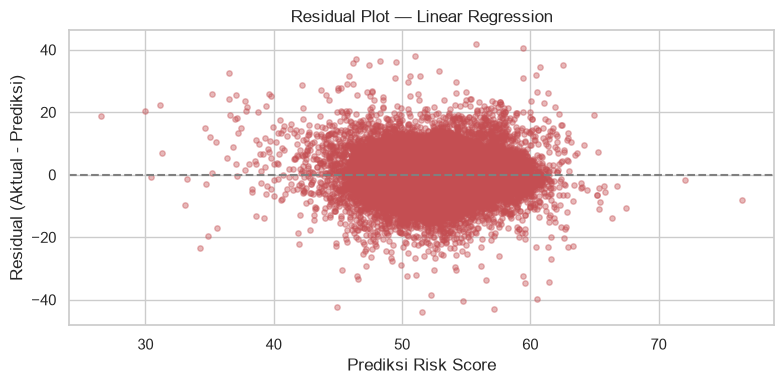

In [13]:
# Cek asumsi linearitas: plot residual model Linear Regression
residuals_lr = y_test - y_pred_model
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_model, residuals_lr, alpha=0.4, s=15, color="#C44E52")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Prediksi Risk Score"); plt.ylabel("Residual (Aktual - Prediksi)")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout(); plt.show()

# 5. Model Evaluation vs Baseline

Ukur performa model di data yang **tidak pernah dilihat model selama training**
(`test_df`), lalu bandingkan **eksplisit** dengan baseline non-ML dari Bagian 2. Ini
langkah paling penting: kalau model tidak mengalahkan baseline, itu bukan aib —
itu **temuan valid** yang harus didokumentasikan jujur.

In [14]:
final_results_df = pd.DataFrame(results).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.742,4.958,-0.000
1,Baseline: Rata-rata per Sel,3.275,4.471,0.187
2,Baseline: Rata-rata per Jam+Hari,3.468,4.635,0.126
3,"Baseline: Rata-rata per (Sel, Jam)",3.630,4.916,0.017
4,"Baseline: Rata-rata per (Sel, Hari)",3.657,4.960,-0.001
5,Model: Linear Regression,3.042,4.181,0.289
6,Model: Random Forest,1.278,2.307,0.783
7,Model: Gradient Boosting,2.790,3.835,0.402


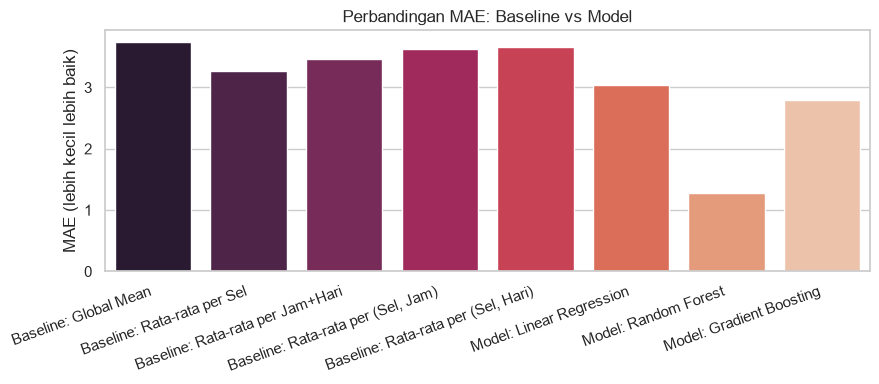

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=final_results_df, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Baseline vs Model")
plt.ylabel("MAE (lebih kecil lebih baik)"); plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

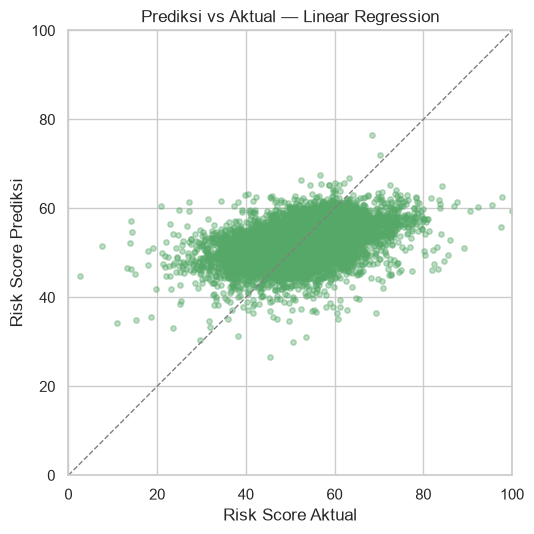

In [16]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred_model, alpha=0.4, s=15, color="#55A868")
lims = [0, 100]
plt.plot(lims, lims, "--", color="gray", linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Risk Score Aktual"); plt.ylabel("Risk Score Prediksi")
plt.title("Prediksi vs Aktual — Linear Regression")
plt.tight_layout(); plt.show()

### 🙋 Giliran Kalian — Evaluasi

- Apakah model mengungguli **semua** baseline, atau hanya sebagian? Analisis kenapa.
- MAE, RMSE, dan R² masing-masing mengukur hal yang sedikit berbeda (mis. RMSE lebih
  sensitif ke *outlier* dibanding MAE). Jelaskan di laporan metrik mana yang paling
  relevan untuk konteks Risk Score, dan kenapa.
- Lihat plot prediksi vs aktual — di rentang nilai mana model paling sering salah?
  Apakah ada pola pada residualnya?
- Kalau model kalian **tidak** mengalahkan baseline: itu valid! Tuliskan analisis kritis
  kenapa itu bisa terjadi (fitur kurang informatif? model terlalu sederhana/kompleks?
  data terlalu noisy?), bukan hanya melaporkan angkanya.

In [17]:
final_results_df = pd.DataFrame(results).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.742,4.958,-0.000
1,Baseline: Rata-rata per Sel,3.275,4.471,0.187
2,Baseline: Rata-rata per Jam+Hari,3.468,4.635,0.126
3,"Baseline: Rata-rata per (Sel, Jam)",3.630,4.916,0.017
4,"Baseline: Rata-rata per (Sel, Hari)",3.657,4.960,-0.001
5,Model: Linear Regression,3.042,4.181,0.289
6,Model: Random Forest,1.278,2.307,0.783
7,Model: Gradient Boosting,2.790,3.835,0.402


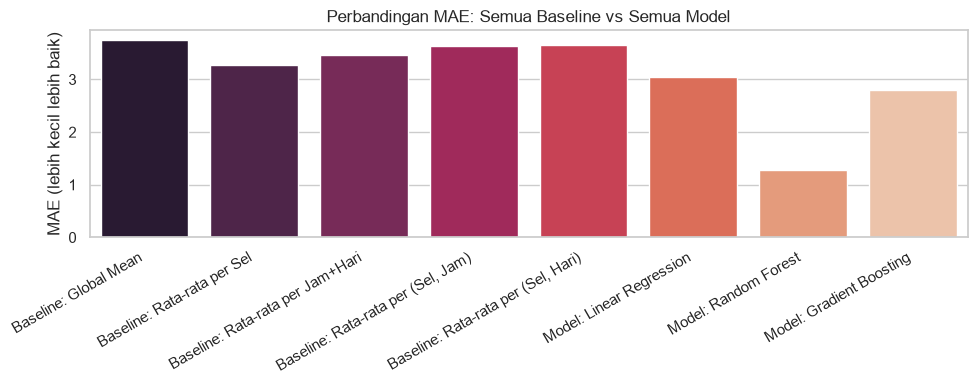

In [18]:
plt.figure(figsize=(10, 4))
sns.barplot(data=final_results_df, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Semua Baseline vs Semua Model")
plt.ylabel("MAE (lebih kecil lebih baik)"); plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

Model terbaik: Model: Random Forest


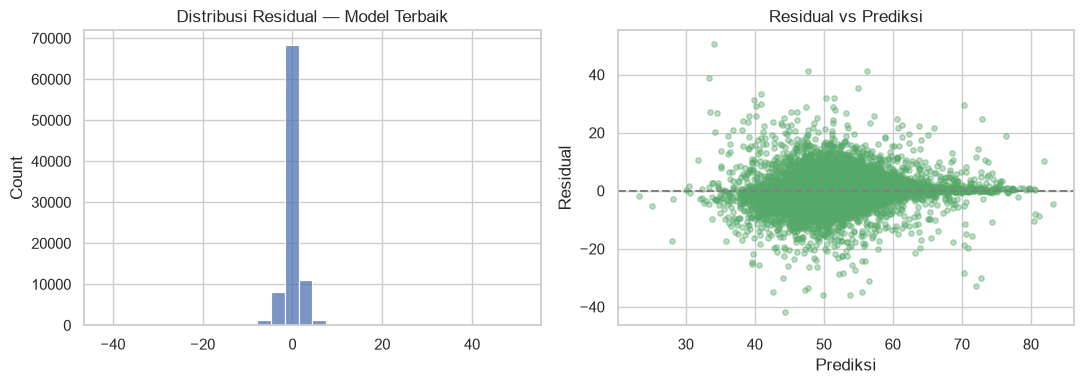

In [19]:
# Pilih model terbaik (MAE terkecil) sebagai fokus analisis residual & segmen
best_model_row = final_results_df.loc[final_results_df["model"].str.startswith("Model:")].sort_values("MAE").iloc[0]
print("Model terbaik:", best_model_row["model"])

best_pred_map = {"Model: Linear Regression": y_pred_model, "Model: Random Forest": y_pred_rf,
                  "Model: Gradient Boosting": y_pred_gbm}
y_pred_best = best_pred_map[best_model_row["model"]]
residuals_best = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(residuals_best, bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribusi Residual — Model Terbaik")
axes[1].scatter(y_pred_best, residuals_best, alpha=0.4, s=15, color="#55A868")
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Prediksi")
plt.tight_layout(); plt.show()

In [20]:
# Evaluasi per segmen: akhir pekan vs hari kerja 
if "is_weekend" in test_df.columns:
    seg_results = []
    for seg_val, seg_name in [(0, "Hari Kerja"), (1, "Akhir Pekan")]:
        mask = test_df["is_weekend"] == seg_val
        if mask.sum() > 0:
            seg_results.append(evaluate(y_test[mask.values], y_pred_best[mask.values], seg_name))
    pd.DataFrame(seg_results).round(3)
else:
    print("Kolom 'is_weekend' tidak tersedia di dataset ini (mis. data sintetis) — segmentasi dilewati.")

# 6. Continual Learning — Simulasi Kedatangan Data Bertahap

Model yang dilatih sekali **tidak selalu relevan selamanya**. Pola kejahatan bisa
berubah seiring waktu (musim, kebijakan, kejadian tak terduga) — fenomena ini disebut
**data drift**. *Continual learning* adalah praktik memperbarui model secara
**terstruktur** agar tetap relevan, alih-alih mengabaikannya atau melatih ulang secara
sembarangan setiap saat.

> ⚠️ **Keterbatasan data yang perlu kalian sadari.** Dataset `features_labels.csv` dari
> Hands-On 1 sudah **diagregasi** per (sel × hari × jam) — informasi *tanggal kejadian
> sebenarnya* (`Datetime`) sudah "melebur" ke dalam agregat dan tidak ada lagi di file
> ini. Supaya notebook ini tetap bisa mendemonstrasikan mekanisme continual learning,
> kita **mensimulasikan** kedatangan data secara berurutan dengan mengacak lalu memotong
> data menjadi beberapa "batch", dan sengaja **menyuntikkan drift buatan** ke batch-batch
> akhir supaya ada sesuatu yang bisa dideteksi. Ini simulasi pedagogis, **bukan urutan
> waktu asli**.
>
> 🙋 **Giliran Kalian (penting!):** cara yang lebih jujur secara metodologis adalah
> kembali ke dataframe **per-kejadian** dari Hands-On 1 (yang masih punya kolom
> `Datetime` sebelum diagregasi), lalu susun batch berdasarkan **urutan waktu asli**
> (mis. per bulan atau per minggu), baru agregasi ulang jadi fitur per batch. Itu akan
> menghasilkan simulasi drift yang jauh lebih realistis daripada pengacakan buatan di
> bawah ini.

In [21]:
# --- Pisahkan HOLDOUT yang TIDAK PERNAH dipakai untuk training di seluruh proses ---
# holdout_df = test_df dari Bagian 2 (frozen, dipakai konsisten di semua versi model)
holdout_df = test_df.copy()

# --- Pool data yang akan "mengalir" sebagai batch-batch continual learning ---
stream_df = train_df.copy().reset_index(drop=True)

N_BATCHES = 5
DRIFT_START_BATCH = 3   # batch dengan indeks >= ini akan diberi drift buatan

# Versi SEDERHANA: acak urutan lalu potong jadi N_BATCHES bagian -> "pura-pura" urut waktu
stream_shuffled = stream_df.sample(frac=1.0, random_state=7).reset_index(drop=True)
batch_size = len(stream_shuffled) // N_BATCHES

batches = []
for i in range(N_BATCHES):
    start = i * batch_size
    end = len(stream_shuffled) if i == N_BATCHES - 1 else (i + 1) * batch_size
    batches.append(stream_shuffled.iloc[start:end].copy().reset_index(drop=True))

# --- Suntikkan drift buatan ke batch-batch akhir (demo, bukan drift asli!) ---
rng = np.random.default_rng(123)
for i in range(DRIFT_START_BATCH, N_BATCHES):
    b = batches[i]
    noise = rng.normal(0, 1.5, size=len(b)).clip(min=0)
    b["crime_count"] = (b["crime_count"] * 1.6 + noise).round().astype(int)
    b["risk_score"] = (b["risk_score"] * 1.3).clip(upper=100)
    batches[i] = b

for i, b in enumerate(batches):
    tag = " (drift buatan)" if i >= DRIFT_START_BATCH else ""
    print(f"Batch {i}: {len(b)} baris{tag}")

Batch 0: 73231 baris
Batch 1: 73231 baris
Batch 2: 73231 baris
Batch 3: 73231 baris (drift buatan)
Batch 4: 73232 baris (drift buatan)


### 🙋 Giliran Kalian — Simulasi Batch

- Kembangkan skema batching yang lebih realistis (lihat catatan di atas soal
  `Datetime`), atau minimal jelaskan **asumsi & keterbatasan** skema pengacakan ini di
  laporan.
- Berapa jumlah batch yang wajar? Apakah 5 batch ini merepresentasikan skenario
  "data datang mingguan", "bulanan", atau yang lain? Sesuaikan dengan cerita yang ingin
  kalian bangun di laporan ("model journey").

In [22]:
# ASUMSI PENTING: file features_labels.csv di sini adalah data teragregasi
# (per sel x hari x jam), TANPA kolom Datetime per-kejadian. Karena itu urutan
# waktu asli tidak bisa direkonstruksi di notebook ini, dan simulasi batch
# TETAP berbasis pengacakan -- ini keterbatasan metodologis yang didokumentasikan,
# bukan diklaim sebagai urutan waktu nyata.
#
# Perbaikan yang kami terapkan dibanding versi sederhana:
# - Stratifikasi per cell_id, supaya tiap batch tetap merepresentasikan
#   sebaran lokasi yang mirip (bukan kebetulan 1 batch didominasi sel tertentu).
# - Fungsi dibuat reusable supaya jumlah batch & titik mulai drift mudah diuji ulang.

def make_stratified_batches(stream_df, n_batches, group_col="cell_id", random_state=7):
    """Bagi stream_df jadi n_batches, stratifikasi per group_col agar tiap batch
    punya proporsi kelompok yang mirip (mendekati sampling acak terstratifikasi)."""
    parts = [[] for _ in range(n_batches)]
    for _, group in stream_df.groupby(group_col):
        group_shuffled = group.sample(frac=1.0, random_state=random_state)
        indices = np.array_split(group_shuffled.index, n_batches)
        splits = [group_shuffled.loc[idx] for idx in indices]
        for i, s in enumerate(splits):
            parts[i].append(s)
    batches_ = [pd.concat(p, ignore_index=True) if p else pd.DataFrame(columns=stream_df.columns)
                for p in parts]
    return batches_

holdout_df = test_df.copy()
stream_df = train_df.copy().reset_index(drop=True)

N_BATCHES = 5
DRIFT_START_BATCH = 3

batches = make_stratified_batches(stream_df, N_BATCHES)

rng = np.random.default_rng(123)
for i in range(DRIFT_START_BATCH, N_BATCHES):
    b = batches[i]
    noise = rng.normal(0, 1.5, size=len(b)).clip(min=0)
    b["crime_count"] = (b["crime_count"] * 1.6 + noise).round().astype(int)
    b["risk_score"] = (b["risk_score"] * 1.3).clip(upper=100)
    batches[i] = b

for i, b in enumerate(batches):
    tag = " (drift buatan)" if i >= DRIFT_START_BATCH else ""
    n_unique_cells = b["cell_id"].nunique()
    print(f"Batch {i}: {len(b)} baris, {n_unique_cells} sel unik{tag}")

Batch 0: 90513 baris, 37160 sel unik
Batch 1: 80224 baris, 31699 sel unik
Batch 2: 71909 baris, 27704 sel unik
Batch 3: 64799 baris, 24451 sel unik (drift buatan)
Batch 4: 58711 baris, 21695 sel unik (drift buatan)


# 7. Drift Detection

Sebelum retrain, kita perlu tahu: **apakah batch data baru ini benar-benar berbeda**
secara statistik dari data yang dipakai untuk melatih model saat ini? Kalau tidak, tidak
perlu buang-buang komputasi untuk retrain.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai **uji Kolmogorov–Smirnov dua-sampel**
> (`scipy.stats.ks_2samp`) untuk membandingkan distribusi beberapa kolom numerik antara
> data referensi (yang dipakai melatih model saat ini) vs batch baru. Kalau *p-value*
> di bawah ambang batas (`alpha`) untuk **salah satu** kolom yang dicek, kita anggap
> drift terdeteksi.

In [23]:
DRIFT_COLUMNS = ["crime_count", "risk_score"]
DRIFT_ALPHA = 0.01  # ambang batas p-value -> makin kecil, makin "ketat" syarat drift

def detect_drift(reference_df, new_batch_df, columns=DRIFT_COLUMNS, alpha=DRIFT_ALPHA):
    """Deteksi drift SEDERHANA: uji KS dua-sampel per kolom numerik.

    p_value < alpha  ->  distribusi dianggap berbeda signifikan (drift terdeteksi).
    """
    report = {}
    drift_detected = False
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        is_drift = bool(p_value < alpha)
        report[col] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": is_drift}
        if is_drift:
            drift_detected = True
    return drift_detected, report

# Contoh: cek batch 0 (tanpa drift buatan) vs batch terakhir (dengan drift buatan)
drift_flag, report = detect_drift(batches[0], batches[-1])
print("Drift terdeteksi:", drift_flag)
for col, info in report.items():
    print(f"  {col}: ks_stat={info['ks_stat']:.3f}, p_value={info['p_value']:.4f}, drift={info['drift']}")

Drift terdeteksi: True
  crime_count: ks_stat=0.878, p_value=0.0000, drift=True
  risk_score: ks_stat=0.894, p_value=0.0000, drift=True


### 🙋 Giliran Kalian — Drift Detection

Ini bagian penting dari **Continual Learning (35%)**:
- Uji KS hanya membandingkan distribusi **satu kolom pada satu waktu** (*univariate*).
  Coba metrik lain: **Population Stability Index (PSI)** (lihat referensi Evidently AI
  di akhir notebook), perbandingan mean/std sederhana dengan ambang batas, atau metode
  *multivariate drift* yang membandingkan distribusi gabungan seluruh fitur sekaligus.
- Selain **drift pada fitur** (mis. `crime_count`), pertimbangkan juga **drift pada
  label** (`risk_score`) atau bahkan *concept drift* (hubungan fitur→label yang berubah,
  bukan cuma distribusinya).
- Bagaimana kalian menentukan `DRIFT_ALPHA`/ambang batas? Ini keputusan yang harus
  **dijustifikasi**, bukan angka sembarang — jelaskan trade-off antara terlalu sensitif
  (retrain terlalu sering, boros komputasi) vs kurang sensitif (model jadi usang).

In [24]:
def population_stability_index(expected, actual, bins=10):
    """PSI: bandingkan distribusi 'expected' (referensi) vs 'actual' (batch baru).
    PSI < 0.1: stabil | 0.1-0.25: perubahan sedang | > 0.25: perubahan signifikan."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    # Hindari log(0) dengan epsilon kecil
    eps = 1e-6
    expected_pct = np.clip(expected_pct, eps, None)
    actual_pct = np.clip(actual_pct, eps, None)
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return float(psi)

DRIFT_COLUMNS = ["crime_count", "risk_score"]
DRIFT_ALPHA = 0.01     # ambang p-value untuk KS
PSI_THRESHOLD = 0.25   # ambang PSI untuk dianggap "signifikan"

def detect_drift(reference_df, new_batch_df, champion_model=None,
                  columns=DRIFT_COLUMNS, alpha=DRIFT_ALPHA, psi_threshold=PSI_THRESHOLD):
    """Deteksi drift multi-kriteria:
    1) KS test per kolom (univariate, distribusi fitur/label)
    2) PSI per kolom (univariate, lebih stabil untuk sample besar)
    3) Concept drift proxy: distribusi RESIDUAL champion model bergeser signifikan
       antara referensi vs batch baru -> menandakan hubungan fitur->label berubah,
       bukan cuma distribusi datanya.
    """
    report = {}
    drift_detected = False
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        psi_val = population_stability_index(reference_df[col].values, new_batch_df[col].values)
        is_drift = bool(p_value < alpha) or bool(psi_val > psi_threshold)
        report[col] = {"ks_stat": float(stat), "p_value": float(p_value),
                       "psi": psi_val, "drift": is_drift}
        if is_drift:
            drift_detected = True

    concept_drift = None
    if champion_model is not None:
        X_ref = assemble_features(reference_df)
        X_new = assemble_features(new_batch_df)
        resid_ref = reference_df[TARGET_COL].values - champion_model.predict(X_ref)
        resid_new = new_batch_df[TARGET_COL].values - champion_model.predict(X_new)
        stat_c, p_c = ks_2samp(resid_ref, resid_new)
        concept_drift = bool(p_c < alpha)
        report["concept_drift_residual"] = {"ks_stat": float(stat_c), "p_value": float(p_c),
                                             "drift": concept_drift}
        if concept_drift:
            drift_detected = True

    return drift_detected, report

# Contoh cek: batch 0 (tanpa drift buatan) vs batch terakhir (dengan drift buatan)
drift_flag, report = detect_drift(batches[0], batches[-1])
print("Drift terdeteksi:", drift_flag)
for col, info in report.items():
    print(f"  {col}: {info}")

Drift terdeteksi: True
  crime_count: {'ks_stat': 0.8783158220366135, 'p_value': 0.0, 'psi': 13.870426900831019, 'drift': True}
  risk_score: {'ks_stat': 0.8937098660722682, 'p_value': 0.0, 'psi': 4.903106518058905, 'drift': True}


# 8. Checkpoint Retraining & Model Versioning

Sekarang kita rangkai semuanya menjadi satu **siklus continual learning**:
1. Model awal (**champion**) dilatih dari batch pertama.
2. Untuk tiap batch baru yang "tiba": jalankan **drift detection** terhadap data
   yang sedang dipakai training saat ini.
3. Kalau **tidak ada drift signifikan** → skip retrain, cukup tambahkan batch ke pool
   data untuk pertimbangan berikutnya.
4. Kalau **ada drift** → latih **kandidat** model baru dari seluruh data yang terkumpul
   sampai saat itu (checkpoint), lalu **evaluasi di holdout yang sama** (fixed, tidak
   pernah dipakai training) supaya perbandingan antar-versi model adil.
5. **Champion vs Challenger**: kandidat hanya **dipromosikan** jadi champion baru kalau
   metriknya (MAE) lebih baik atau sama dengan champion saat ini. Kalau lebih buruk,
   champion lama tetap dipakai — dan ini **dicatat**, bukan disembunyikan.
6. Setiap versi (baik yang dipromosikan maupun tidak) **disimpan sebagai checkpoint**
   dan **dicatat di registry**.

In [25]:
os.makedirs("models", exist_ok=True)
REGISTRY_PATH = "models/registry.json"
registry = []

def train_model(data_subset):
    X = assemble_features(data_subset)
    y = data_subset[TARGET_COL].values
    m = LinearRegression()
    m.fit(X, y)
    return m

def evaluate_model(fitted_model, data_eval):
    X = assemble_features(data_eval)
    y = data_eval[TARGET_COL].values
    y_pred = fitted_model.predict(X)
    return {
        "MAE": float(mean_absolute_error(y, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, y_pred))),
        "R2": float(r2_score(y, y_pred)),
    }

def save_checkpoint(fitted_model, version):
    path = f"models/model_v{version}.joblib"
    joblib.dump(fitted_model, path)
    return path

def log_registry(entry):
    registry.append(entry)
    with open(REGISTRY_PATH, "w") as f:
        json.dump(registry, f, indent=2)

In [26]:
# --- Versi 0: model awal (champion) dilatih dari batch pertama ---
cumulative_train = batches[0].copy()
champion_model = train_model(cumulative_train)
champion_metrics = evaluate_model(champion_model, holdout_df)

version = 0
checkpoint_path = save_checkpoint(champion_model, version)
log_registry({
    "version": version,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "batch_index": 0,
    "train_size": len(cumulative_train),
    "drift_detected": None,
    "drift_report": None,
    "metrics": champion_metrics,
    "decision": "initial_champion",
    "checkpoint_path": checkpoint_path,
})
print(f"[v{version}] Model awal dilatih dari batch 0 ({len(cumulative_train)} baris). "
      f"MAE holdout = {champion_metrics['MAE']:.3f}")

[v0] Model awal dilatih dari batch 0 (90513 baris). MAE holdout = 3.081


In [27]:
PROMOTE_MARGIN = 0.0  # kandidat harus MAE-nya <= (champion_MAE - margin) untuk dipromosikan

for i in range(1, N_BATCHES):
    new_batch = batches[i]
    drift_detected, drift_report = detect_drift(cumulative_train, new_batch)

    print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) ===")
    print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")
    for col, info in drift_report.items():
        print(f"  {col}: p-value={info['p_value']:.4f} -> drift={info['drift']}")

    if not drift_detected:
        # Tidak retrain -> cukup tambahkan batch ke pool data untuk pertimbangan berikutnya
        cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)
        log_registry({
            "version": None,
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "batch_index": i,
            "train_size": len(cumulative_train),
            "drift_detected": drift_detected,
            "drift_report": drift_report,
            "metrics": None,
            "decision": "skip_retrain_no_drift",
            "checkpoint_path": None,
        })
        continue

    # Drift terdeteksi -> latih kandidat model baru (checkpoint retraining)
    cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)
    candidate_model = train_model(cumulative_train)
    candidate_metrics = evaluate_model(candidate_model, holdout_df)

    version += 1
    checkpoint_path = save_checkpoint(candidate_model, version)

    improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
    decision = "promoted" if improved else "kept_champion"

    print(f"[v{version}] Kandidat dilatih dari {len(cumulative_train)} baris. "
          f"MAE kandidat={candidate_metrics['MAE']:.3f} vs "
          f"MAE champion={champion_metrics['MAE']:.3f} -> {decision}")

    log_registry({
        "version": version,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "batch_index": i,
        "train_size": len(cumulative_train),
        "drift_detected": drift_detected,
        "drift_report": drift_report,
        "metrics": candidate_metrics,
        "champion_metrics_before": champion_metrics,
        "decision": decision,
        "checkpoint_path": checkpoint_path,
    })

    if improved:
        champion_model = candidate_model
        champion_metrics = candidate_metrics

print("\n=== Selesai ===")
print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))


=== Batch 1 tiba (80224 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0150 -> drift=False
  risk_score: p-value=0.0000 -> drift=True
[v1] Kandidat dilatih dari 170737 baris. MAE kandidat=3.080 vs MAE champion=3.081 -> promoted

=== Batch 2 tiba (71909 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.0000 -> drift=True
[v2] Kandidat dilatih dari 242646 baris. MAE kandidat=3.079 vs MAE champion=3.080 -> promoted

=== Batch 3 tiba (64799 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.0000 -> drift=True
[v3] Kandidat dilatih dari 307445 baris. MAE kandidat=3.910 vs MAE champion=3.079 -> kept_champion

=== Batch 4 tiba (58711 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.0000 -> drift=True
[v4] Kandidat dilatih dari 366156 baris. MAE kandidat=4.568 vs MAE champion=3.079 -> kept_champion

=== Selesai ===
Champion akhir -> MAE holdout: 3

### 🙋 Giliran Kalian — Checkpoint Retraining & Versioning

Ini **komponen inti** yang paling besar bobotnya (35%). Kembangkan versi sederhana di
atas:
- Kriteria promosi sekarang hanya "MAE kandidat ≤ MAE champion". Apakah ini cukup ketat?
  Pertimbangkan margin peningkatan minimum (`PROMOTE_MARGIN`), atau evaluasi di beberapa
  metrik sekaligus (MAE **dan** R², misalnya) sebelum promosi.
- Sekarang kandidat selalu dilatih dari **seluruh** data kumulatif (`cumulative_train`).
  Apakah strategi lain (mis. *sliding window*, memberi bobot lebih besar ke data
  terbaru, atau *fine-tuning* dari model sebelumnya alih-alih retrain dari nol) lebih
  masuk akal untuk skenario data drift seperti ini?
- Model apa yang kalian pakai di `train_model()`? Kalau kalian sudah mengganti model di
  Bagian 4, pastikan fungsi ini konsisten memakainya.
- **Dokumentasikan setiap keputusan** — baik yang berhasil (`promoted`) maupun yang
  gagal (`kept_champion`) — beserta alasannya. Rekam jejak inilah yang membentuk
  "narasi perjalanan model" (*model journey*) yang diminta di laporan.

In [28]:
os.makedirs("models", exist_ok=True)
REGISTRY_PATH = "models/registry.json"
registry = []

# Strategi training: "full" (semua data kumulatif) atau "sliding_window" (hanya N batch terakhir)
TRAIN_STRATEGY = "sliding_window"
SLIDING_WINDOW_BATCHES = 3

MODEL_TYPE = "RandomForestRegressor"
MODEL_HYPERPARAMS = {"n_estimators": 300, "min_samples_leaf": 3, "random_state": 42, "n_jobs": -1}

def train_model(data_subset):
    X = assemble_features(data_subset)
    y = data_subset[TARGET_COL].values
    m = RandomForestRegressor(**MODEL_HYPERPARAMS)
    m.fit(X, y)
    return m

def evaluate_model(fitted_model, data_eval):
    X = assemble_features(data_eval)
    y = data_eval[TARGET_COL].values
    y_pred = fitted_model.predict(X)
    return {
        "MAE": float(mean_absolute_error(y, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, y_pred))),
        "R2": float(r2_score(y, y_pred)),
    }

def save_checkpoint(fitted_model, version):
    path = f"models/model_v{version}.joblib"
    joblib.dump(fitted_model, path)
    return path

def log_registry(entry):
    registry.append(entry)
    with open(REGISTRY_PATH, "w") as f:
        json.dump(registry, f, indent=2)

def get_training_window(all_batches_so_far, strategy=TRAIN_STRATEGY, window=SLIDING_WINDOW_BATCHES):
    """Pilih subset batch untuk training sesuai strategi."""
    if strategy == "sliding_window":
        selected = all_batches_so_far[-window:]
        return pd.concat(selected, ignore_index=True)
    return pd.concat(all_batches_so_far, ignore_index=True)  # "full"

def should_promote(candidate_metrics, champion_metrics, mae_margin=0.1, allow_r2_drop=0.01):
    """Kriteria promosi ganda (lebih ketat dari sekadar MAE lebih kecil):
    - MAE kandidat harus lebih baik dari champion minimal sebesar mae_margin.
    - R2 kandidat tidak boleh turun lebih dari allow_r2_drop dibanding champion."""
    mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - mae_margin
    r2_ok = candidate_metrics["R2"] >= champion_metrics["R2"] - allow_r2_drop
    return bool(mae_improved and r2_ok)

PROMOTE_MARGIN = 0.1

In [29]:
# --- Versi 0: model awal (champion) dilatih dari batch pertama ---
batch_history = [batches[0].copy()]
cumulative_train = batch_history[0]
champion_model = train_model(cumulative_train)
champion_metrics = evaluate_model(champion_model, holdout_df)

version = 0
checkpoint_path = save_checkpoint(champion_model, version)
log_registry({
    "version": version,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "batch_index": 0,
    "train_size": len(cumulative_train),
    "train_strategy": TRAIN_STRATEGY,
    "model_type": MODEL_TYPE,
    "hyperparams": MODEL_HYPERPARAMS,
    "feature_cols": FEATURE_COLS_FINAL,
    "drift_detected": None,
    "drift_report": None,
    "metrics": champion_metrics,
    "decision": "initial_champion",
    "trigger_reason": "initial_training",
    "checkpoint_path": checkpoint_path,
})
print(f"[v{version}] Model awal ({MODEL_TYPE}) dilatih dari batch 0 ({len(cumulative_train)} baris). "
      f"MAE holdout = {champion_metrics['MAE']:.3f}, R2 = {champion_metrics['R2']:.3f}")

[v0] Model awal (RandomForestRegressor) dilatih dari batch 0 (90513 baris). MAE holdout = 2.451, R2 = 0.452


In [30]:
for i in range(1, N_BATCHES):
    new_batch = batches[i]
    drift_detected, drift_report = detect_drift(cumulative_train, new_batch, champion_model=champion_model)

    print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) ===")
    print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")
    for col, info in drift_report.items():
        print(f"  {col}: {info}")

    batch_history.append(new_batch)

    if not drift_detected:
        cumulative_train = get_training_window(batch_history)
        log_registry({
            "version": None, "timestamp": datetime.now(timezone.utc).isoformat(),
            "batch_index": i, "train_size": len(cumulative_train), "train_strategy": TRAIN_STRATEGY,
            "model_type": MODEL_TYPE, "hyperparams": MODEL_HYPERPARAMS,
            "feature_cols": FEATURE_COLS_FINAL, "drift_detected": drift_detected,
            "drift_report": drift_report, "metrics": None,
            "decision": "skip_retrain_no_drift", "trigger_reason": "no_drift",
            "checkpoint_path": None,
        })
        continue

    # Drift terdeteksi -> latih kandidat model baru (sesuai strategi window)
    cumulative_train = get_training_window(batch_history)
    candidate_model = train_model(cumulative_train)
    candidate_metrics = evaluate_model(candidate_model, holdout_df)

    version += 1
    checkpoint_path = save_checkpoint(candidate_model, version)
    promote = should_promote(candidate_metrics, champion_metrics, mae_margin=PROMOTE_MARGIN)
    decision = "promoted" if promote else "kept_champion"

    print(f"[v{version}] Kandidat dilatih dari {len(cumulative_train)} baris ({TRAIN_STRATEGY}). "
          f"MAE kandidat={candidate_metrics['MAE']:.3f}, R2={candidate_metrics['R2']:.3f} vs "
          f"MAE champion={champion_metrics['MAE']:.3f}, R2={champion_metrics['R2']:.3f} -> {decision}")

    log_registry({
        "version": version, "timestamp": datetime.now(timezone.utc).isoformat(),
        "batch_index": i, "train_size": len(cumulative_train), "train_strategy": TRAIN_STRATEGY,
        "model_type": MODEL_TYPE, "hyperparams": MODEL_HYPERPARAMS,
        "feature_cols": FEATURE_COLS_FINAL, "drift_detected": drift_detected,
        "drift_report": drift_report, "metrics": candidate_metrics,
        "champion_metrics_before": champion_metrics, "decision": decision,
        "trigger_reason": "drift_detected", "promote_margin": PROMOTE_MARGIN,
        "checkpoint_path": checkpoint_path,
    })

    if promote:
        champion_model = candidate_model
        champion_metrics = candidate_metrics

print("\n=== Selesai ===")
print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3),
      "| R2:", round(champion_metrics["R2"], 3))


=== Batch 1 tiba (80224 baris) ===
Drift terdeteksi!
  crime_count: {'ks_stat': 0.0075788854590308485, 'p_value': 0.015031132590058493, 'psi': 0.0005236018892721124, 'drift': False}
  risk_score: {'ks_stat': 0.014224881065177553, 'p_value': 6.635329727081126e-08, 'psi': 0.0012246684722147386, 'drift': True}
  concept_drift_residual: {'ks_stat': 0.13227396919705448, 'p_value': 0.0, 'drift': True}
[v1] Kandidat dilatih dari 170737 baris (sliding_window). MAE kandidat=2.177, R2=0.521 vs MAE champion=2.451, R2=0.452 -> promoted

=== Batch 2 tiba (71909 baris) ===
Drift terdeteksi!
  crime_count: {'ks_stat': 0.015237850344042125, 'p_value': 1.2341161118626962e-10, 'psi': 0.002017284913529613, 'drift': True}
  risk_score: {'ks_stat': 0.016000635964558863, 'p_value': 1.1060634956372874e-11, 'psi': 0.0018581194545611913, 'drift': True}
  concept_drift_residual: {'ks_stat': 0.11554976232117703, 'p_value': 0.0, 'drift': True}
[v2] Kandidat dilatih dari 242646 baris (sliding_window). MAE kandida

# 9. Model Registry & Checkpoints

Setiap versi model — dipromosikan atau tidak — sudah tercatat di `models/registry.json`
dan checkpoint-nya tersimpan sebagai file `.joblib` di folder `models/`. Ini adalah
bentuk paling sederhana dari **model versioning**: tidak butuh infrastruktur rumit,
tapi tetap informatif dan bisa ditelusuri kapan saja tanpa membongkar kode.

In [31]:
print("Isi folder models/:")
for f in sorted(os.listdir("models")):
    print(" -", f)

Isi folder models/:
 - model_v0.joblib
 - model_v1.joblib
 - model_v2.joblib
 - model_v3.joblib
 - model_v4.joblib
 - registry.json


In [32]:
registry_df = pd.json_normalize(registry)
registry_df

,version,timestamp,batch_index,train_size,train_strategy,model_type,feature_cols,drift_detected,drift_report,decision,trigger_reason,checkpoint_path,hyperparams.n_estimators,hyperparams.min_samples_leaf,hyperparams.random_state,hyperparams.n_jobs,metrics.MAE,metrics.RMSE,metrics.R2,promote_margin,drift_report.crime_count.ks_stat,drift_report.crime_count.p_value,drift_report.crime_count.psi,drift_report.crime_count.drift,drift_report.risk_score.ks_stat,drift_report.risk_score.p_value,drift_report.risk_score.psi,drift_report.risk_score.drift,drift_report.concept_drift_residual.ks_stat,drift_report.concept_drift_residual.p_value,drift_report.concept_drift_residual.drift,champion_metrics_before.MAE,champion_metrics_before.RMSE,champion_metrics_before.R2
0,0,2026-07-26T09:56:03.005611+00:00,0,90513,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",None,NaN,initial_champion,initial_training,models/model_v0.joblib,300,3,42,-1,2.451276,3.669825,0.452120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2026-07-26T09:56:32.468878+00:00,1,170737,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,promoted,drift_detected,models/model_v1.joblib,300,3,42,-1,2.177033,3.432959,0.520563,0.1,0.007579,1.503113e-02,0.000524,False,0.014225,6.635330e-08,0.001225,True,0.132274,0.0,True,2.451276,3.669825,0.452120
2,2,2026-07-26T09:57:13.789670+00:00,2,242646,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,promoted,drift_detected,models/model_v2.joblib,300,3,42,-1,1.984186,3.255608,0.568820,0.1,0.015238,1.234116e-10,0.002017,True,0.016001,1.106063e-11,0.001858,True,0.115550,0.0,True,2.177033,3.432959,0.520563
3,3,2026-07-26T09:57:53.510552+00:00,3,216932,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,kept_champion,drift_detected,models/model_v3.joblib,300,3,42,-1,2.989605,4.758645,0.078784,0.1,0.870239,0.000000e+00,13.678910,True,0.888888,0.000000e+00,4.792368,True,0.981659,0.0,True,1.984186,3.255608,0.568820
4,4,2026-07-26T09:58:28.488528+00:00,4,195419,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,kept_champion,drift_detected,models/model_v4.joblib,300,3,42,-1,3.668125,5.651218,-0.299208,0.1,0.606923,0.000000e+00,8.652365,True,0.626942,0.000000e+00,2.561718,True,0.689130,0.0,True,1.984186,3.255608,0.568820


### 🙋 Giliran Kalian — Registry

- Informasi apa lagi yang perlu dicatat di registry supaya kalian (atau orang lain) bisa
  memahami riwayat model tanpa membongkar kode? Misalnya: hash/versi dataset yang
  dipakai, hyperparameter model, siapa/apa yang memicu retrain, waktu training.
- Format registry di sini adalah JSON (list of dict). Format lain seperti CSV/SQLite
  juga valid — pilih yang menurut kalian paling sesuai, dan **konsistenlah**
  menggunakannya di setiap versi.

In [33]:
import hashlib

def dataset_hash(data_subset, cols=None):
    """Hash MD5 dari isi data (setelah sort) -> jejak persis data yang dipakai training."""
    cols = cols or sorted(data_subset.columns)
    payload = data_subset[cols].sort_values(cols).to_csv(index=False).encode("utf-8")
    return hashlib.md5(payload).hexdigest()[:12]

In [34]:
registry_df = pd.json_normalize(registry)
registry_df

,version,timestamp,batch_index,train_size,train_strategy,model_type,feature_cols,drift_detected,drift_report,decision,trigger_reason,checkpoint_path,hyperparams.n_estimators,hyperparams.min_samples_leaf,hyperparams.random_state,hyperparams.n_jobs,metrics.MAE,metrics.RMSE,metrics.R2,promote_margin,drift_report.crime_count.ks_stat,drift_report.crime_count.p_value,drift_report.crime_count.psi,drift_report.crime_count.drift,drift_report.risk_score.ks_stat,drift_report.risk_score.p_value,drift_report.risk_score.psi,drift_report.risk_score.drift,drift_report.concept_drift_residual.ks_stat,drift_report.concept_drift_residual.p_value,drift_report.concept_drift_residual.drift,champion_metrics_before.MAE,champion_metrics_before.RMSE,champion_metrics_before.R2
0,0,2026-07-26T09:56:03.005611+00:00,0,90513,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",None,NaN,initial_champion,initial_training,models/model_v0.joblib,300,3,42,-1,2.451276,3.669825,0.452120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2026-07-26T09:56:32.468878+00:00,1,170737,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,promoted,drift_detected,models/model_v1.joblib,300,3,42,-1,2.177033,3.432959,0.520563,0.1,0.007579,1.503113e-02,0.000524,False,0.014225,6.635330e-08,0.001225,True,0.132274,0.0,True,2.451276,3.669825,0.452120
2,2,2026-07-26T09:57:13.789670+00:00,2,242646,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,promoted,drift_detected,models/model_v2.joblib,300,3,42,-1,1.984186,3.255608,0.568820,0.1,0.015238,1.234116e-10,0.002017,True,0.016001,1.106063e-11,0.001858,True,0.115550,0.0,True,2.177033,3.432959,0.520563
3,3,2026-07-26T09:57:53.510552+00:00,3,216932,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,kept_champion,drift_detected,models/model_v3.joblib,300,3,42,-1,2.989605,4.758645,0.078784,0.1,0.870239,0.000000e+00,13.678910,True,0.888888,0.000000e+00,4.792368,True,0.981659,0.0,True,1.984186,3.255608,0.568820
4,4,2026-07-26T09:58:28.488528+00:00,4,195419,sliding_window,RandomForestRegressor,"[lat_r, lon_r, hour_sin, hour_cos, dow_sin, do...",True,NaN,kept_champion,drift_detected,models/model_v4.joblib,300,3,42,-1,3.668125,5.651218,-0.299208,0.1,0.606923,0.000000e+00,8.652365,True,0.626942,0.000000e+00,2.561718,True,0.689130,0.0,True,1.984186,3.255608,0.568820


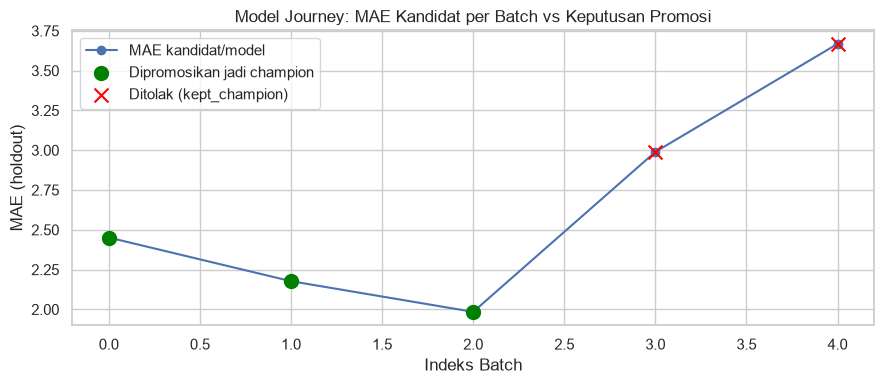

In [35]:
# --- "Model Journey": bagaimana performa champion berkembang sepanjang versi ---
history = registry_df[registry_df["metrics.MAE"].notna()].copy()
history = history.sort_values("batch_index")

plt.figure(figsize=(9, 4))
plt.plot(history["batch_index"], history["metrics.MAE"], marker="o", label="MAE kandidat/model")
promoted_points = history[history["decision"].isin(["initial_champion", "promoted"])]
plt.scatter(promoted_points["batch_index"], promoted_points["metrics.MAE"],
            color="green", s=100, zorder=5, label="Dipromosikan jadi champion")
kept_points = history[history["decision"] == "kept_champion"]
plt.scatter(kept_points["batch_index"], kept_points["metrics.MAE"],
            color="red", marker="x", s=100, zorder=5, label="Ditolak (kept_champion)")
plt.xlabel("Indeks Batch"); plt.ylabel("MAE (holdout)")
plt.title("Model Journey: MAE Kandidat per Batch vs Keputusan Promosi")
plt.legend(); plt.tight_layout(); plt.show()

In [36]:
# --- Ringkasan tekstual siklus retraining, tanpa perlu buka kode ---
summary_cols = ["version", "batch_index", "train_size", "train_strategy",
                "drift_detected", "decision", "trigger_reason", "dataset_hash"]
available_cols = [c for c in summary_cols if c in registry_df.columns]
print("Ringkasan siklus retraining:")
registry_df[available_cols]

Ringkasan siklus retraining:


,version,batch_index,train_size,train_strategy,drift_detected,decision,trigger_reason
0,0,0,90513,sliding_window,None,initial_champion,initial_training
1,1,1,170737,sliding_window,True,promoted,drift_detected
2,2,2,242646,sliding_window,True,promoted,drift_detected
3,3,3,216932,sliding_window,True,kept_champion,drift_detected
4,4,4,195419,sliding_window,True,kept_champion,drift_detected


In [37]:
# --- Verifikasi reproducibility: checkpoint yang tersimpan bisa dimuat ulang & cocok dengan registry ---
for entry in registry:
    if entry.get("checkpoint_path"):
        loaded_model = joblib.load(entry["checkpoint_path"])
        reloaded_metrics = evaluate_model(loaded_model, holdout_df)
        match = abs(reloaded_metrics["MAE"] - entry["metrics"]["MAE"]) < 1e-6
        print(f"v{entry['version']}: checkpoint valid = {match}")

v0: checkpoint valid = True
v1: checkpoint valid = True
v2: checkpoint valid = True
v3: checkpoint valid = True
v4: checkpoint valid = True


# 10. Ringkasan & Langkah Selanjutnya

Yang sudah kita hasilkan lewat **versi baseline** ini:
- **Baseline non-ML** (historical average) sebagai patokan minimal.
- **Feature vector assembly** yang konsisten via `assemble_features()`.
- **Model regresi** (Linear Regression) yang dievaluasi eksplisit terhadap baseline.
- **Simulasi continual learning**: kedatangan data bertahap, deteksi drift (uji KS),
  checkpoint retraining bersyarat, logika champion/challenger, dan model registry.

### ⚠️ Ingat: ini baru titik awal
Notebook ini sengaja memakai versi paling sederhana di tiap komponen inti. Ringkasan
**apa yang masih terbuka untuk kalian kembangkan** (dan inilah yang dinilai):

| Komponen | Versi baseline di tutorial | Ruang pengembangan kalian |
| :-- | :-- | :-- |
| Baseline non-ML | Global mean / per-sel / per-jam+hari | Kombinasi pola, strategi fallback yang lebih baik |
| Feature vector | Fitur numerik siap pakai, `cell_id` dibuang | Encoding lokasi (target/frequency encoding), seleksi fitur |
| Model regresi | `LinearRegression` | Model ensemble/non-linear (Random Forest, Gradient Boosting), tuning |
| Evaluasi | MAE/RMSE/R² vs baseline | Analisis residual, evaluasi per segmen (lokasi/waktu) |
| Simulasi batch | Acak + drift buatan | Batch berbasis waktu asli (dari data per-kejadian HO1) |
| Drift detection | Uji KS univariate, ambang tetap | PSI, drift multivariate, drift pada label/konsep |
| Retraining & versioning | Champion/challenger sederhana, retrain dari nol | Margin promosi, sliding window, registry yang lebih kaya |

> 🧠 **Inti penilaian:** bagian **continual learning (drift detection, checkpoint
> retraining, versioning)** dinilai paling besar (35%) — bukan dari kesempurnaan angka
> MAE, tapi dari **seberapa jujur dan masuk akal** narasi keputusan yang kalian ambil di
> setiap checkpoint. Kalau model kalian tidak mengalahkan baseline, atau model baru hasil
> retrain ternyata lebih buruk, itu **temuan valid** — dokumentasikan dengan jujur.

Selamat mengerjakan Hands-On 2! 🙂